# Land Cover Classicfication
**An ML pipeline for classifying land covers from the Eurosat dataset**\
In this notebook, I use the EuroSAT dataset to classify different types of land cover. Since Random Forest and XGBoost cannot work directly with images, I first extract a few simple features from each image (RGB mean and standard deviation) and then train both models. Finally, I compare their performance using accuracy, F1-score, confusion matrices, and some sample predictions.

## Load EuroSAT data

In [1]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root= r'C:\Users\sreya\jpynb\2750', transform=transform)

print(f"Total samples : {len(dataset)}")
print(f"Classes : {dataset.classes}")
print(dataset[0])

Total samples : 27000
Classes : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
(tensor([[[0.5843, 0.5765, 0.5725,  ..., 0.4000, 0.4078, 0.4039],
         [0.5843, 0.5843, 0.5843,  ..., 0.4000, 0.4078, 0.4039],
         [0.5608, 0.5647, 0.5765,  ..., 0.4000, 0.4000, 0.4039],
         ...,
         [0.5529, 0.5529, 0.5373,  ..., 0.4039, 0.3922, 0.3961],
         [0.5098, 0.5176, 0.5059,  ..., 0.4118, 0.4118, 0.4196],
         [0.4784, 0.4784, 0.4706,  ..., 0.4157, 0.4157, 0.4196]],

        [[0.4745, 0.4745, 0.4706,  ..., 0.3529, 0.3608, 0.3569],
         [0.4745, 0.4745, 0.4667,  ..., 0.3529, 0.3608, 0.3569],
         [0.4588, 0.4510, 0.4549,  ..., 0.3608, 0.3529, 0.3569],
         ...,
         [0.4588, 0.4588, 0.4588,  ..., 0.3647, 0.3529, 0.3529],
         [0.4353, 0.4392, 0.4314,  ..., 0.3686, 0.3647, 0.3725],
         [0.4157, 0.4118, 0.4039,  ..., 0.3725, 0.3725, 0.3725]],

        [[0.4706, 

## Feature Extraction

**Might add more per-channel features like median, min, max later which might improve model accuracy for both RF and XGBoost**

In [2]:
from tqdm.notebook import tqdm

def extract_features(dataset):
    features, labels = [], []
    loader = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=0)
    for imgs, lbls in tqdm(loader, desc="Extracting Features"):
        mean = imgs.mean(dim=[2, 3])
        std  = imgs.std(dim=[2, 3])
        feat_batch = torch.cat([mean, std], dim=1)
        features.append(feat_batch.numpy())
        labels.append(lbls.numpy())
    return np.vstack(features), np.concatenate(labels)

X, y = extract_features(dataset)
print(f"Feature matrix: {X.shape}")
print(f"Labels : {y.shape}")

Extracting Features:   0%|          | 0/53 [00:00<?, ?it/s]

Feature matrix: (27000, 6)
Labels : (27000,)


## Train/Test split and Normalize

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## A) RandomForestClassifier

**Adjusted these levers for better accuracy**

In [15]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features='log2',
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

t0 = time.time()
rf.fit(X_train, y_train)
print(f"RF trained in {time.time() - t0:.1f}s")

y_pred_rf = rf.predict(X_test)

RF trained in 8.3s


## B) XGBoost

In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
xgb.fit(X_train, y_train)
print(f"XGB trained in {time.time() - t0:.1f}s")

y_pred_xgb = xgb.predict(X_test)

XGB trained in 8.7s


## Accuracy

In [17]:
from sklearn.metrics import classification_report, accuracy_score

classes = dataset.classes

print("RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=classes))

print("=" * 69)

print("XGBOOST")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=classes))

RANDOM FOREST
Accuracy: 0.7709
                      precision    recall  f1-score   support

          AnnualCrop       0.77      0.78      0.78       600
              Forest       0.94      0.94      0.94       600
HerbaceousVegetation       0.76      0.70      0.73       600
             Highway       0.52      0.41      0.46       500
          Industrial       0.83      0.91      0.87       500
             Pasture       0.75      0.88      0.81       400
       PermanentCrop       0.64      0.63      0.64       500
         Residential       0.74      0.85      0.79       600
               River       0.67      0.66      0.67       500
             SeaLake       0.96      0.90      0.93       600

            accuracy                           0.77      5400
           macro avg       0.76      0.77      0.76      5400
        weighted avg       0.77      0.77      0.77      5400

XGBOOST
Accuracy: 0.7802
                      precision    recall  f1-score   support

          

## Confusion Matrices

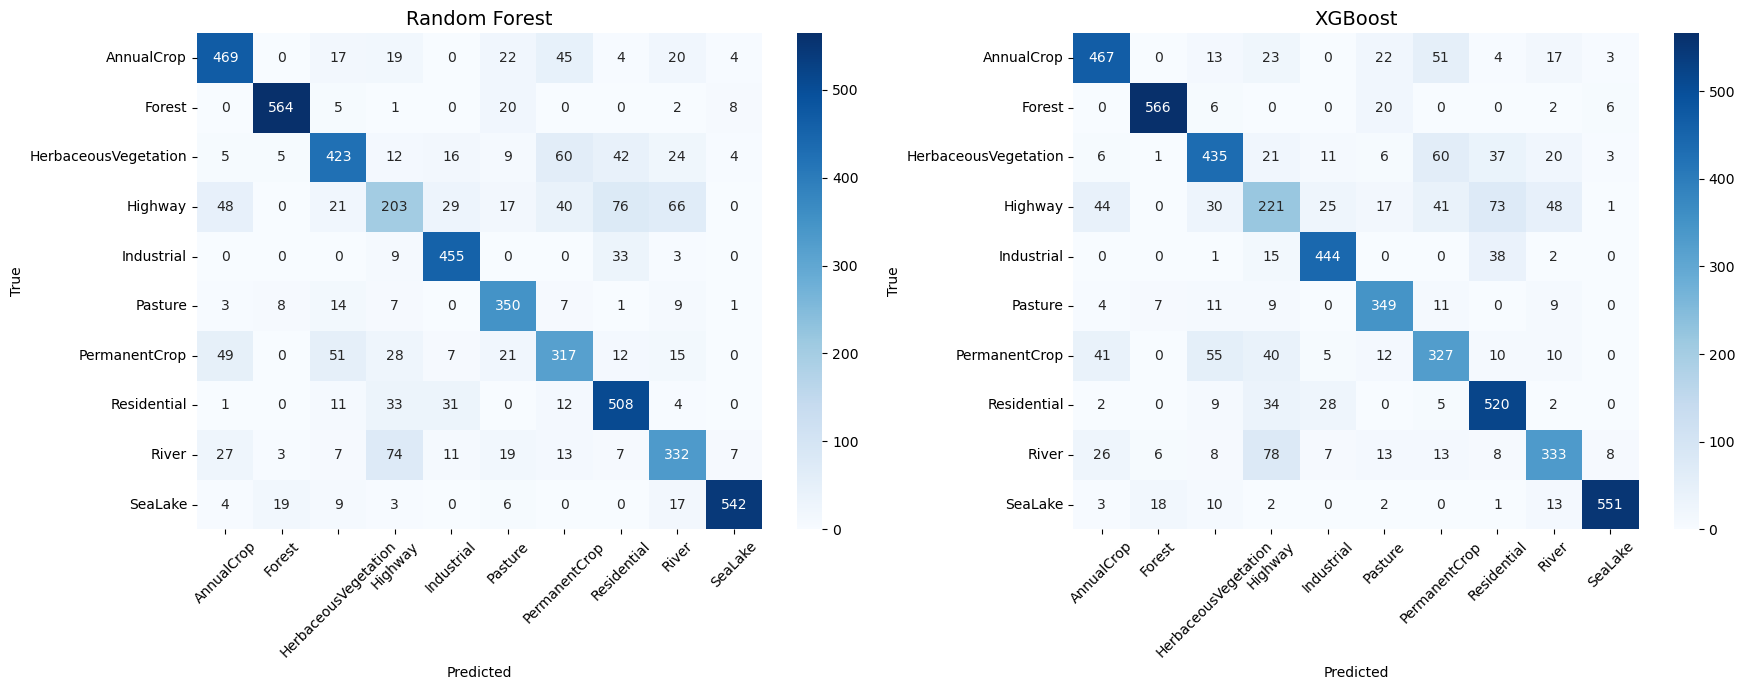

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes, yticklabels=classes, ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualize Predictions

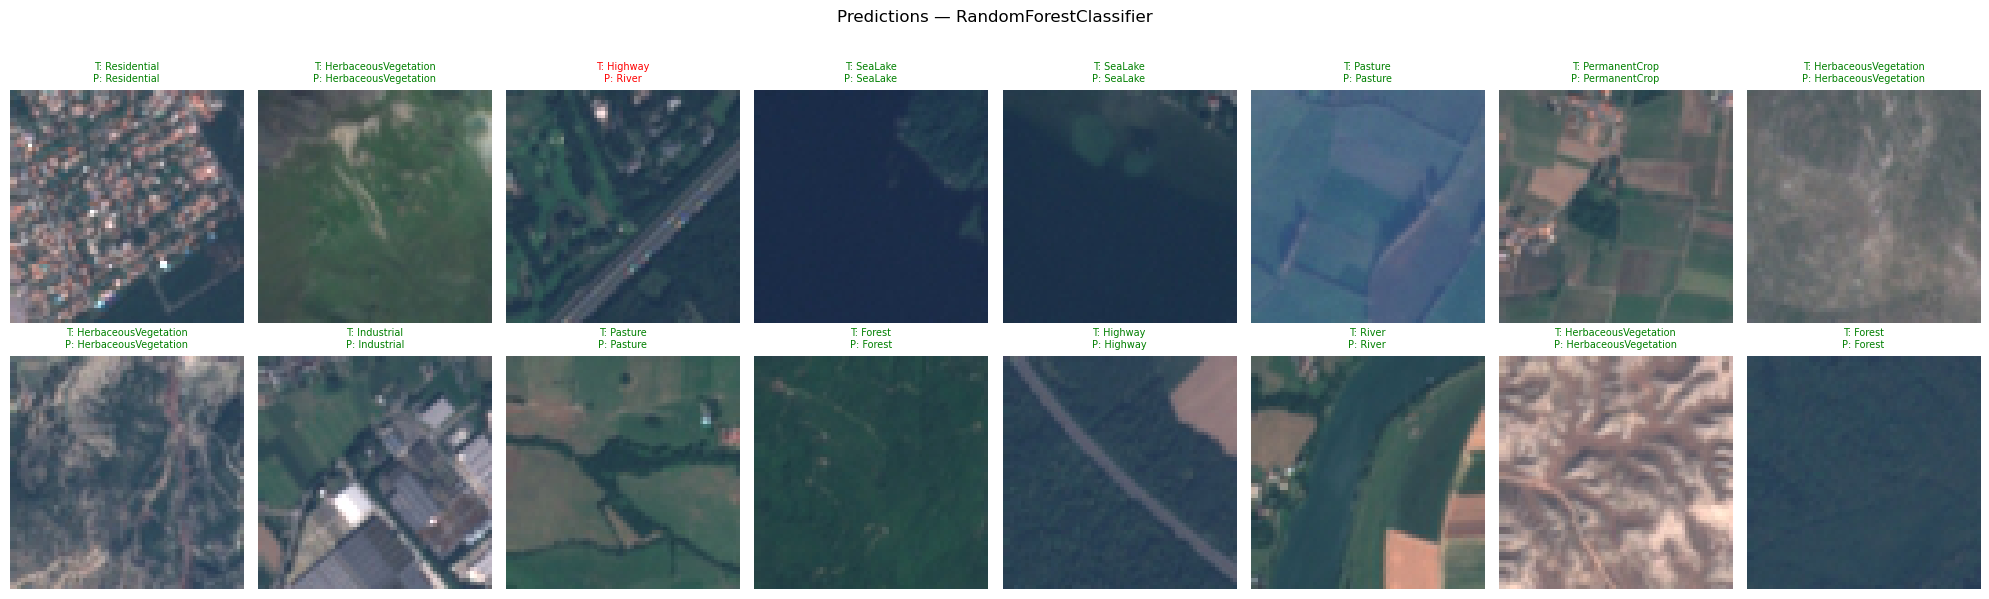

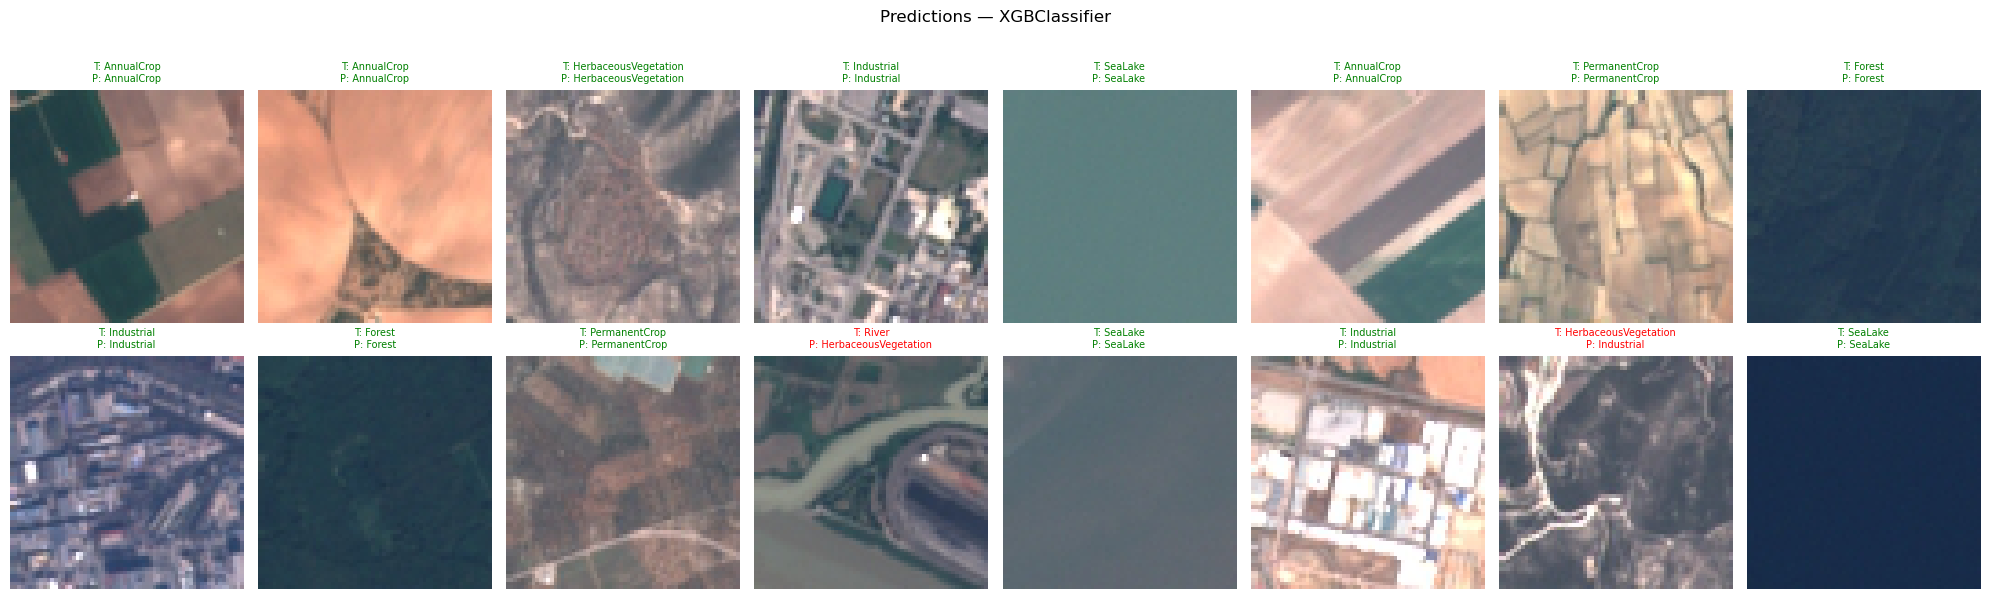

In [21]:
from torchvision.utils import make_grid

def show_predictions(dataset, model, scaler, n=16):
    idxs = np.random.choice(len(dataset), n, replace=False)
    
    imgs, trues, preds = [], [], []
    for i in idxs:
        img, label = dataset[i]
        f = np.concatenate([
            img.mean(dim=[1,2]).numpy(),
            img.std(dim=[1,2]).numpy()
        ]).reshape(1, -1)
        p = model.predict(scaler.transform(f))[0]
        imgs.append(img)
        trues.append(dataset.classes[label])
        preds.append(dataset.classes[p])

    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    axes = axes.flatten()
    
    for i, (img, t, p) in enumerate(zip(imgs, trues, preds)):
        axes[i].imshow(img.permute(1,2,0).numpy())
        axes[i].set_title(f"T: {t}\nP: {p}", fontsize=7,
                          color='green' if t == p else 'red')
        axes[i].axis('off')

    name = model.__class__.__name__
    plt.suptitle(f"Predictions — {name}", y=1.02)
    plt.tight_layout()
    plt.savefig(f'predictions_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(dataset, rf, scaler)
show_predictions(dataset, xgb, scaler)

## Model Comparison

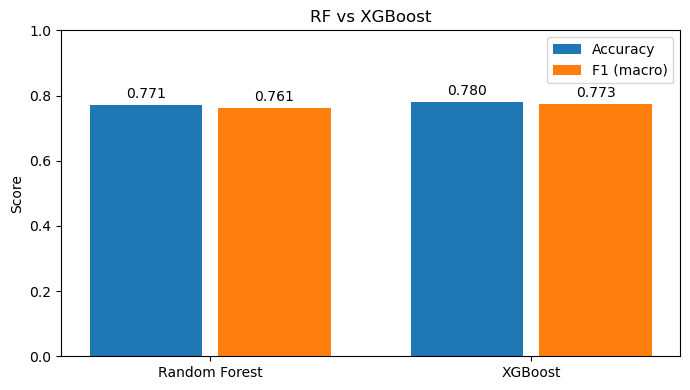

In [22]:
from sklearn.metrics import accuracy_score, f1_score

acc_rf  = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_rf   = f1_score(y_test, y_pred_rf,  average='macro')
f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')

models = ['Random Forest', 'XGBoost']
accs = [acc_rf, acc_xgb]
f1s  = [f1_rf,  f1_xgb]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(models))

b1 = ax.bar(x - 0.2, accs, 0.35, label='Accuracy')
b2 = ax.bar(x + 0.2, f1s,  0.35, label='F1 (macro)')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('RF vs XGBoost')
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3)
ax.bar_label(b2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()